In [1]:
#
# assure le reload de src si modifications sont faite
#
%load_ext autoreload
%autoreload 2

In [2]:
#
# import utilitaires
#
%matplotlib inline

import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from pathlib import Path

In [3]:
#
# import package develope pour le projet
#
import ffury
from ffury.configs import create_config, DEFAULT_CONFIG_FILE
from ffury.dataset import load_dataset_raw

# creation config - on sait que DEFAULT_CONFIG_FILE est dans le repertoire parent
config = Path(ffury.__file__).parents[2].joinpath(DEFAULT_CONFIG_FILE)
config = create_config(config)

# load dataset BirdCLEF
raw_df = load_dataset_raw(config)

In [4]:
print("Information sur le data:", config.dataset.data_description_url)

Information sur le data: https://www.kaggle.com/competitions/birdclef-2023/data


In [5]:
print("Dataset shape:", raw_df.shape)

print()

print("Types")
display(raw_df.dtypes.to_frame().T)

print()

print("Affichage succint")
display(raw_df.head())

Dataset shape: (16941, 12)

Types


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,author,license,rating,url,filename
0,object,object,object,float64,float64,object,object,object,object,float64,object,object



Affichage succint


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,author,license,rating,url,filename
0,abethr1,[],['song'],4.3906,38.2788,Turdus tephronotus,African Bare-eyed Thrush,Rolf A. de By,Creative Commons Attribution-NonCommercial-Sha...,4.0,https://www.xeno-canto.org/128013,abethr1/XC128013.ogg
1,abethr1,[],['call'],-2.9524,38.2921,Turdus tephronotus,African Bare-eyed Thrush,James Bradley,Creative Commons Attribution-NonCommercial-Sha...,3.5,https://www.xeno-canto.org/363501,abethr1/XC363501.ogg
2,abethr1,[],['song'],-2.9524,38.2921,Turdus tephronotus,African Bare-eyed Thrush,James Bradley,Creative Commons Attribution-NonCommercial-Sha...,3.5,https://www.xeno-canto.org/363502,abethr1/XC363502.ogg
3,abethr1,[],['song'],-2.9524,38.2921,Turdus tephronotus,African Bare-eyed Thrush,James Bradley,Creative Commons Attribution-NonCommercial-Sha...,5.0,https://www.xeno-canto.org/363503,abethr1/XC363503.ogg
4,abethr1,[],"['call', 'song']",-2.9524,38.2921,Turdus tephronotus,African Bare-eyed Thrush,James Bradley,Creative Commons Attribution-NonCommercial-Sha...,4.5,https://www.xeno-canto.org/363504,abethr1/XC363504.ogg


<div class="answer">

* 16941 echantillons
* 12 variables. Selon les informations trouvees via l'url et un examin visuel, les variables interessantes sont:
    - **primary_label**: identification de l'oiseau (examiner si cet attribut est deja contenu dans filename)
    - **latitude** & **longitude**: coordonnes de l'enregistrement audio (garde pour usage eventuel)
    - **filename**: nom du fichier audio
    - **url**: url sur informations complementaires. Bien qu'utile, juge non necessaire puisque audio est deja present dans les donnes et images/metadata sont aussi disponible via primary_label.
    - **common_name**: comme url, utile mais redondant.
* les variables sont en fait des fichiers audio (donnees de type numerique) augmentees avec les latitudes & longitudes
* la variable cible est categorique

In [6]:
#
# ne garder que les attributs d'interets
#
data_df = raw_df[[
    "primary_label", 
    "latitude", 
    "longitude", 
    "filename"
]]
print("Attributs d'interet")
display(data_df.head())

Attributs d'interet


,primary_label,latitude,longitude,filename
0,abethr1,4.3906,38.2788,abethr1/XC128013.ogg
1,abethr1,-2.9524,38.2921,abethr1/XC363501.ogg
2,abethr1,-2.9524,38.2921,abethr1/XC363502.ogg
3,abethr1,-2.9524,38.2921,abethr1/XC363503.ogg
4,abethr1,-2.9524,38.2921,abethr1/XC363504.ogg


In [7]:
#
# explorer les valeurs manquantes
#
na_indices = data_df.isna()
na_rows = na_indices.any(axis=1)
na_num = na_rows.sum()

print(f"Quantite de valeurs manquantes: {na_num} ({na_num / data_df.shape[0] % 100:0.2f}%)")

print("Quelques valeurs manquantes")
display(data_df[na_rows].head())

Quantite de valeurs manquantes: 227 (0.01%)
Quelques valeurs manquantes


,primary_label,latitude,longitude,filename
10,abethr1,NaN,NaN,abethr1/XC585802.ogg
220,afecuc1,NaN,NaN,afecuc1/XC118454.ogg
913,barswa,NaN,NaN,barswa/XC169360.ogg
914,barswa,NaN,NaN,barswa/XC171221.ogg
916,barswa,NaN,NaN,barswa/XC171624.ogg


<div class="answer">

* Inspection dans .csv source montre bien que les valeurs sont manquantes
* Comme il n'y en a que tres peut, on les enleves

In [8]:
#
# Enlever NA
#
print("Shape avant:", data_df.shape)
valid_data_df = data_df[~na_rows]
print("Shape apres:", valid_data_df.shape)

Shape avant: (16941, 4)
Shape apres: (16714, 4)


In [9]:
#
# explorer doublons
#
dup_rows = valid_data_df.duplicated()
dup_num = dup_rows.sum()

print("Quantite de doublons:", dup_num)

Quantite de doublons: 0


In [10]:
#
# examiner distribution primary_label (espece)
#
unique_bird = valid_data_df.value_counts("primary_label")
print("Nombre d'especes:", unique_bird.shape[0])

Nombre d'especes: 264


<div class="answer">

* 264 correspond au nombres d'especes attendu dans le dataset (selon description de la competition)

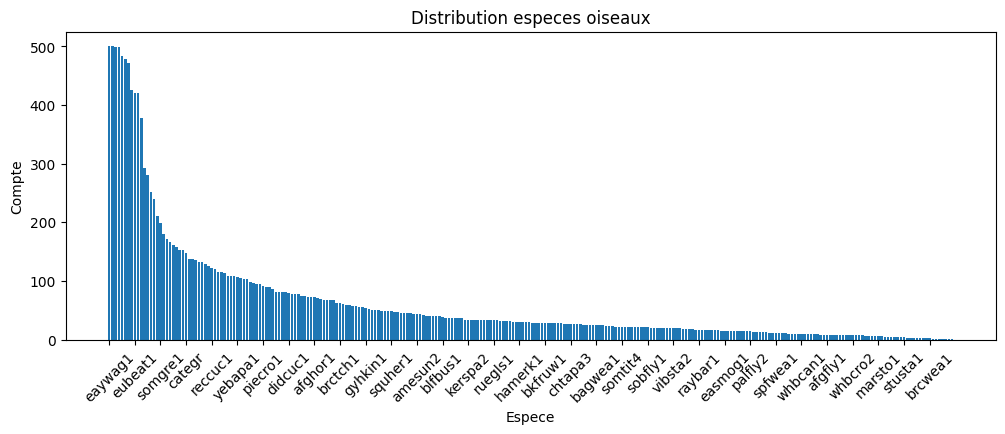

,count,mean,std,min,25%,50%,75%,max
count,264.0,63.310606,96.99807,1.0,14.0,29.5,70.25,500.0


In [11]:
plt.figure(figsize=(12, 4))

count = unique_bird.shape[0]
step = 8

plt.bar([i for i in range(count)], unique_bird.values)

plt.gca().set_xticks([i for i in range(0, count, step)])
plt.gca().set_xticklabels([unique_bird.index[i] for i in range(0, count, step)], rotation=45)

plt.xlabel("Espece")
plt.ylabel("Compte")
plt.title("Distribution especes oiseaux")
plt.show()

print()

display(unique_bird.to_frame().describe().T)